In [5]:
import sys
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

In [6]:
import Scores_Evaluation.ScoresEvaluator as SE
from InputFileType import InputFileType
from ToolType import ToolType

In [7]:
WORKING_DIR = "/home/aronw/Development/Clans-3D/Scores_Evaluation"
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/small_fasta_files/50.fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/big_tsv_files/1500.tsv"

In [76]:
evaluator = SE.ScoresEvaluator(WORKING_DIR)

In [ ]:
# Generate clans files from example dataset
clans_files = evaluator.generate_clans_files(EXAMPLE_DATASET_TSV, InputFileType.TSV, ToolType.FOLDSEEK, "evalue")
print(clans_files)

Failed to download https://alphafold.ebi.ac.uk/files/AF-A0A653YI63-F1-model_v6.pdb: HTTPSConnectionPool(host='alphafold.ebi.ac.uk', port=443): Read timed out. (read timeout=10)
Failed to download A0A653YI63 from https://alphafold.ebi.ac.uk/api/prediction/A0A653YI63
Failed to download https://alphafold.ebi.ac.uk/files/AF-W8R7W7-F1-model_v6.pdb: HTTPSConnectionPool(host='alphafold.ebi.ac.uk', port=443): Read timed out.
Failed to download W8R7W7 from https://alphafold.ebi.ac.uk/api/prediction/W8R7W7
Failed to download A0A1S1KSN3 from https://alphafold.ebi.ac.uk/api/prediction/A0A1S1KSN3
Downloaded 1496 from 1499 PDB files successfully.
Computing structural similarity with foldseek...
Structural similarity computation with foldseek completed.
Generating CLANS file f/home/aronw/Development/Clans-3D/Scores_Evaluation/1500_cleaned.clans...
CLANS file generated at /home/aronw/Development/Clans-3D/Scores_Evaluation/1500_cleaned.clans


Building a new DB, current time: 01/26/2026 12:03:42
New DB

In [ ]:
# Parameters for clustering with recovered clans.jar The first entry in each tuple is for structure-based clans, the second for sequence-based clans.
PATH_TO_CLANS_JAR = "/home/aronw/Development/Clans-3D/recovered_CLANS/clans_working_version.jar" # path to clans jar file
CLUSTER_ROUNDS: tuple[int, int] = (10000, 10000) # sets the number of rounds for clustering in recovered clans
P_VALUES: tuple[float, float] = (1E-10, 1E-29) # sets the p-value threshold for clustering in recovered clans for (structure, sequence)
CLUSTER_2D: tuple[bool, bool] = (False, False) # whether to use 2D clustering in recovered clans
VERBOSE: bool = True # whether to print verbose output from recovered clans

In [ ]:
# Cluster the generated clans files
clustered_clans_files = evaluator.cluster_clans_files(PATH_TO_CLANS_JAR, clans_files, CLUSTER_ROUNDS, P_VALUES, CLUSTER_2D, VERBOSE)
print(clustered_clans_files)

In [8]:
import Scores_Evaluation.ScoresEvaluator as SE
evaluator = SE.ScoresEvaluator(WORKING_DIR)
clustered_clans_files = ("/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans",
                         "/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans")

In [9]:
# Extract data from clustered CLANS files
df_scores, df_euclidean_dist, df_coord = evaluator.extract_data_from_clans_files(clustered_clans_files)
display(df_scores.head())
display(df_euclidean_dist.head())
display(df_coord.head())


Evaluating clustered clans files: /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans and /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans...


,Sequence_ID_1,Sequence_ID_2,Score_struct,Score_-log10_struct,Score_seq,Score_-log10_seq
0,A0A010TDP2,A0A0C5ERJ6,6.898000e-11,10.161277,1.270000e-49,48.896196
1,A0A010TDP2,A0A0D5XUC7,6.622000e-11,10.179011,1.270000e-49,48.896196
2,A0A010TDP2,A0A0D6SYC0,1.373000e-10,9.862329,1.290000e-46,45.889410
3,A0A010TDP2,A0A0F4VEF5,6.622000e-11,10.179011,1.270000e-49,48.896196
4,A0A010TDP2,A0A0J6GDG7,6.898000e-11,10.161277,1.270000e-49,48.896196


,Sequence_ID_1,Sequence_ID_2,euclidean_dist_struct,euclidean_dist_min_max_struct,euclidean_dist_seq,euclidean_dist_min_max_seq
0,C5BN68,A0A559QIZ0,48.038396,0.384708,0.995627,0.010808
1,C5BN68,A0A1Y6BVX3,86.937196,0.697035,1.408443,0.015942
2,C5BN68,Q21FA0,64.267181,0.515012,1.156397,0.012807
3,C5BN68,A0A0T6UN99,85.232253,0.683346,78.579009,0.975781
4,C5BN68,A0A1I3MH02,58.045481,0.465057,78.147779,0.970418


,Sequence_ID,x_struct,y_struct,z_struct,x_seq,y_seq,z_seq
0,A0A010TDP2,-14.461457,-4.747086,7.944270,-10.997788,13.678843,-2.137219
1,A0A023WWI9,13.610619,6.370728,-56.507980,-10.295343,13.362184,-2.018916
2,A0A024EET1,-15.353390,-4.605057,8.372849,-10.517995,14.122930,-1.159340
3,A0A024HPB1,-14.690795,-5.602873,8.212835,-9.950043,14.310882,-1.445684
4,A0A031G2U6,-14.311031,-4.125452,8.489697,-10.691348,13.630973,-1.850832


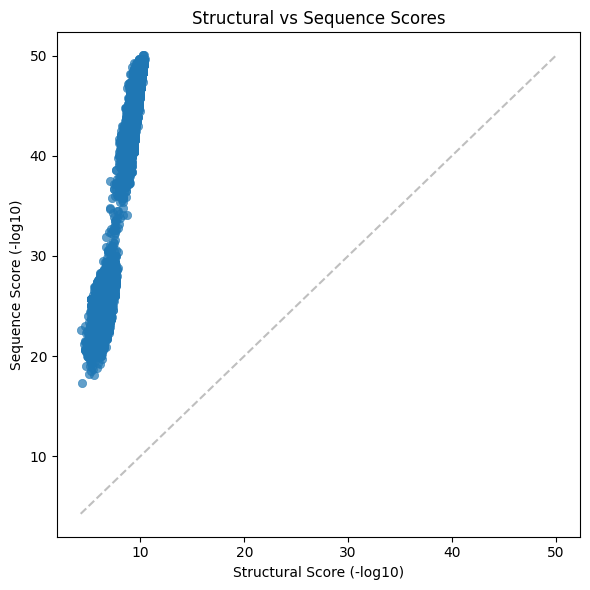

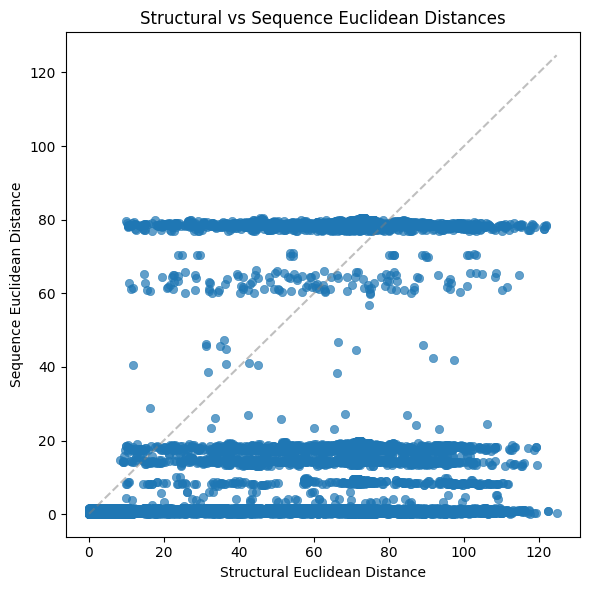

In [16]:
# Generate scatter plots to visualize relationships between scores and euclidian-distances
evaluator.visualizer.generate_scatter_plot(
    data_x=df_scores["Score_-log10_struct"],
    data_y=df_scores["Score_-log10_seq"],
    x_label="Structural Score (-log10)",
    y_label="Sequence Score (-log10)",
    title="Structural vs Sequence Scores"
)

evaluator.visualizer.generate_scatter_plot(
    data_x=df_euclidean_dist["euclidean_dist_struct"],
    data_y=df_euclidean_dist["euclidean_dist_seq"],
    x_label="Structural Euclidean Distance",
    y_label="Sequence Euclidean Distance",
    title="Structural vs Sequence Euclidean Distances"
)

### Interpretation of plots

1: kind of linear but sequence based evalues seem a lot more optimistic than structure based evalues

2: bands show that structural distance seems to be very different whereas sequence distance stays similar

In [23]:
# Find clusters using density-based and graph-based methods
RESOLUTION_PARAMS = (1.007, 1.01)  # (structure, sequence)
df_cluster_labels = evaluator.clustering.find_clusters_density_based(df_coord, "struct")
df_cluster_labels = df_cluster_labels.merge(evaluator.clustering.find_clusters_density_based(df_coord, "seq"), on="Sequence_ID")
df_Leiden_labels = evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_struct", resolution=RESOLUTION_PARAMS[0])
df_Leiden_labels = df_Leiden_labels.merge(evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_seq", resolution=RESOLUTION_PARAMS[1]), on="Sequence_ID")
df_cluster_labels = df_cluster_labels.merge(df_Leiden_labels, on="Sequence_ID")
display(df_cluster_labels)

,Sequence_ID,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden
0,A0A010TDP2,4,2,0,0
1,A0A023WWI9,0,2,1,1
2,A0A024EET1,4,2,0,0
3,A0A024HPB1,4,2,2,2
4,A0A031G2U6,4,2,0,0
...,...,...,...,...,...
488,V9V7Z7,4,2,0,0
489,W6QRK7,-1,2,1,1
490,W6VLX3,4,2,0,0
491,W7QD92,6,1,1,1


In [ ]:
# Display number of clusters and noise found by each method

struct_hdbscan_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_struct_HDBSCAN")
seq_hdbscan_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_seq_HDBSCAN")
struct_leiden_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden")
seq_leiden_counts = evaluator.clustering.get_cluster_counts(df_cluster_labels, "cluster_id_Score_-log10_seq_Leiden")

# expected number of clusters in clans file (500) struct visually 4 - 5
# expected number of clusters in clans file (500) seq visually 3
print(f"HDBSCAN Structure: {struct_hdbscan_counts}")
print(f"HDBSCAN Sequence: {seq_hdbscan_counts}")
print(f"Leiden Structure: {struct_leiden_counts}")
print(f"Leiden Sequence: {seq_leiden_counts}")

HDBSCAN Structure: {'num_clusters': 7, 'num_noise': 46, 'num_clustered': 447}
HDBSCAN Sequence: {'num_clusters': 3, 'num_noise': 0, 'num_clustered': 493}
Leiden Structure: {'num_clusters': 5, 'num_noise': 0, 'num_clustered': 493}
Leiden Sequence: {'num_clusters': 3, 'num_noise': 0, 'num_clustered': 493}
Number of clusters (HDBSCAN - structure): 8
Number of clusters (HDBSCAN - sequence): 3
Number of clusters (Leiden - structure): 5
Number of clusters (Leiden - sequence): 3


### Interpretation

The clustering of the structural file seems to have produced more clusters than the clustering on the sequence file.

Density and network based methods seem to agree on clustered sequence file

In [29]:
# Compute ARI and NMI between structure-based and sequence-based clusterings
clustering_agreement_HDBSCAN = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN")
clustering_agreement_Leiden = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden")
print(f"Clustering agreement (HDBSCAN): {clustering_agreement_HDBSCAN}")
print(f"Clustering agreement (Leiden): {clustering_agreement_Leiden}")

Clustering agreement (HDBSCAN): {'ARI': 0.10164189659601484, 'NMI': 0.113448791423154}
Clustering agreement (Leiden): {'ARI': 0.9679424999000981, 'NMI': 0.9362835568848873}


### Interpretation

ari and nmi with hdbscan very low while very high with network based clustering?

weird

Maybe because hdbscan found a lot more clusters then the network based method

In [26]:
# Compute Jaccard overlap between structure-based and sequence-based clusterings
jaccard_results_HDBSCAN = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN", remove_zero_jaccard=True)
jaccard_results_Leiden = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden", remove_zero_jaccard=True)
print("Jaccard Overlap Results (HDBSCAN - structure vs sequence):")
display(jaccard_results_HDBSCAN)
print("Jaccard Overlap Results (Leiden - structure vs sequence):")
display(jaccard_results_Leiden)


Jaccard Overlap Results (HDBSCAN - structure vs sequence):


,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,JaccardIndex
0,0,2,0.064965
1,1,2,0.076566
2,2,2,0.030162
3,3,2,0.034803
4,4,2,0.689095
5,5,0,0.062500
6,5,1,0.041667
7,5,2,0.025404
8,6,0,0.061224
9,6,1,0.224490


Jaccard Overlap Results (Leiden - structure vs sequence):


,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden,JaccardIndex
0,0,0,0.986885
1,1,1,0.978610
2,2,1,0.015957
3,2,2,0.250000
4,3,0,0.013115
5,4,1,0.005348


### Interpretation

The Jaccard index should show me there are structural clusters very similar to sequence clusters.

In [28]:
# Compute overlap coefficient between structure-based and sequence-based clusterings
overlap_coefficient_HDBSCAN = evaluator.clustering.compute_overlap_coefficient(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN", drop_zero=True)
overlap_coefficient_Leiden = evaluator.clustering.compute_overlap_coefficient(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden", drop_zero=True)
print("Overlap Coefficient Results (HDBSCAN - structure vs sequence):")
display(overlap_coefficient_HDBSCAN)
print("Overlap Coefficient Results (Leiden - structure vs sequence):")
display(overlap_coefficient_Leiden)

Overlap Coefficient Results (HDBSCAN - structure vs sequence):


,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,OverlapCoefficient,is_smaller
0,0,2,1.000000,cluster_id_struct_HDBSCAN
1,1,2,1.000000,cluster_id_struct_HDBSCAN
2,3,2,1.000000,cluster_id_struct_HDBSCAN
3,4,2,1.000000,cluster_id_struct_HDBSCAN
4,5,0,0.250000,cluster_id_seq_HDBSCAN
5,5,1,0.083333,cluster_id_seq_HDBSCAN
6,5,2,0.846154,cluster_id_struct_HDBSCAN
7,6,0,0.750000,cluster_id_seq_HDBSCAN
8,6,1,0.916667,cluster_id_seq_HDBSCAN
9,6,2,0.708333,cluster_id_struct_HDBSCAN


Overlap Coefficient Results (Leiden - structure vs sequence):


,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden,OverlapCoefficient,is_smaller
0,2,1,0.75,cluster_id_Score_-log10_struct_Leiden
1,3,0,1.00,cluster_id_Score_-log10_struct_Leiden
2,4,1,1.00,cluster_id_Score_-log10_struct_Leiden


### Interpretation

The overlap coefficient should show me there are structural clusters that are subsets of sequence clusters. (or the other way around)

In [30]:
# Compute statistics for each cluster for the different clustering methods

# statistics for HDBSCAN structure clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_struct_HDBSCAN",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_struct",
    df_scores=df_scores,
    score_col="Score_-log10_struct"
)
print("Cluster Statistics (HDBSCAN - structure):")
display(stats_per_cluster)

# statistics for HDBSCAN sequence clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_seq_HDBSCAN",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_seq",
    df_scores=df_scores,
    score_col="Score_-log10_seq"
)
print("Cluster Statistics (HDBSCAN - sequence):")
display(stats_per_cluster)

# statistics for Leiden structure clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_Score_-log10_struct_Leiden",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_struct",
    df_scores=df_scores,
    score_col="Score_-log10_struct"
)
print("Cluster Statistics (Leiden - structure):")
display(stats_per_cluster)

# statistics for Leiden sequence clusters
stats_per_cluster = evaluator.clustering.compute_cluster_statistics(
    df_cluster_labels=df_cluster_labels,
    cluster_col="cluster_id_Score_-log10_seq_Leiden",
    df_distances=df_euclidean_dist,
    distance_col="euclidean_dist_min_max_seq",
    df_scores=df_scores,
    score_col="Score_-log10_seq"
)
print("Cluster Statistics (Leiden - sequence):")
display(stats_per_cluster)

Cluster Statistics (HDBSCAN - structure):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,28,0.027642,9.962732
1,1,33,0.064159,9.893197
2,2,13,0.006822,10.041102
3,3,15,0.016687,10.127469
4,4,297,0.006444,10.209058
5,5,13,0.192796,8.232421
6,6,48,0.370343,7.804095


Cluster Statistics (HDBSCAN - sequence):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,10,0.307137,26.603189
1,1,15,0.044361,36.376263
2,2,468,0.010140,46.352968


Cluster Statistics (Leiden - structure):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,301,0.059360,10.192979
1,1,183,0.484072,8.634509
2,2,4,0.539877,9.472662
3,3,4,0.007077,10.107119
4,4,1,NaN,NaN


Cluster Statistics (Leiden - sequence):


,Cluster_ID,num_sequences,mean_distance,mean_score
0,0,305,0.008621,48.872510
1,1,187,0.132505,39.940106
2,2,1,NaN,NaN


# next steps: 

1. create plots of 
    number of clusters found with hdbscan and leiden for structure and sequence based clustering
    ari nmi scores for hdbscan and leiden for structure vs sequence based clustering
    jaccard index, cluster overlap coefficient for hdbscan and leiden for structure vs sequence based clustering
    statistics for each cluster

2. run evaluation with bigger dataset
    find pvalue then cluster

3. make sense of results